# 4 — Modelos de Machine Learning

**Entrada:** `dataset_modelado.csv`, `harmonie_crudo.csv`, `baselines_metricas.csv` (opcional)
**Salida:** `ml_predicciones.parquet`, `ml_mejor_modelo.json`

Cubre la parte de ML del objetivo 2 del Anexo I, en dos etapas:

| Etapa | Qué varía | Qué se fija | Objetivo |
|---|---|---|---|
| **1. Familia** | 5 familias × búsqueda ligera | Los 12 horizontes, ventana 24 h | Justificar *qué* modelo se usa |
| **2. Afinado** | Ventana + hiperparámetros, 150 trials | La familia ganadora | Resultado final por horizonte |

La ventana **no** se fija en una fase previa: entra como un hiperparámetro más de la búsqueda,
porque su óptimo depende de los demás hiperparámetros y varía con el horizonte.

## Decisiones de afinado

| Mejora | Por qué |
|---|---|
| Objetivo `reg:absoluteerror` | La métrica que importa es el MAE, no el error cuadrático |
| Features de tendencia | 3 agregados (media, dispersión, pendiente) frente al ruido de lags sueltos |
| `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda` | Control fino del sobreajuste |
| *Early stopping* real | El nº de árboles lo decide el ajuste, no Optuna adivinando. Más preciso y más rápido |
| `MedianPruner` | Corta trials que van peor que la mediana, concentrando el tiempo donde importa |

## Features

Conjunto **B** de la ablación (notebook 2): lags del anemómetro + cíclicas + velocidad,
dirección y lead de HARMONIE, con `lead_min = H + LATENCIA` para no usar pronósticos
emitidos después del instante de decisión. El bloque atmosférico y la dirección observada
se descartaron allí con evidencia; no se repite esa ablación aquí.

> **Coste.** En la ejecución documentada, la etapa 1 tardó unos 20 min y la etapa 2 unos 79 min (3 horizontes en paralelo × 2 hilos).
> Requiere `pip install xgboost lightgbm optuna shap`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import time, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RUTA        = Path('.')
LATENCIA    = 4
OBJ         = 'obs_vel'
HORIZONTES  = list(range(1, 13))
H_REF       = 12               # horizonte de referencia para la selección de familia
VENTANAS    = [6, 12, 24]      # candidatas; en la etapa 2 son un hiperparámetro más
TRIALS_FAMILIA = 15
TRIALS_AFINADO = 150           # con early stopping cada trial es barato
N_SPLITS_CV = 3
N_ESTIM_MAX = 2000             # techo de árboles; el early stopping decide el real
EARLY_STOP  = 30
SEMILLA     = 42

# --- Paralelismo, ajustado a Apple Silicon (4 núcleos de rendimiento + 6 de eficiencia) --
# Repartir un ajuste entre los 10 núcleos es CONTRAPRODUCENTE: los 6 de eficiencia son
# mucho más lentos y los de rendimiento quedan esperando en cada barrera de sincronización.
# Medido sobre estos datos (11k x 35): n_jobs=4 -> 0.56 s/ajuste frente a 0.74 s con n_jobs=10,
# con MAE idéntico. Como cada ajuste necesita pocos hilos, sale mucho más a cuenta gastar el
# paralelismo en lanzar HORIZONTES a la vez, que son independientes entre sí.
N_JOBS_MODELO   = 2    # hilos por ajuste de XGBoost
N_JOBS_HORIZONTE = 3   # horizontes simultáneos (3 x 2 = 6 hilos, ~0.5 GB cada proceso)
N_JOBS_FAMILIA   = 4   # etapa 1: secuencial, así que cada ajuste puede usar más hilos

plt.rcParams['figure.figsize'] = (11, 4)

base  = pd.read_csv(RUTA/'dataset_modelado.csv', index_col='ts', parse_dates=['ts'])
crudo = pd.read_csv(RUTA/'harmonie_crudo.csv', parse_dates=['valida', 'pasada'])
crudo['V']   = np.hypot(crudo.WSPE, crudo.WSPN)
crudo['Dir'] = (np.degrees(np.arctan2(-crudo.WSPE, -crudo.WSPN)) + 360) % 360

ruta_bl = RUTA/'baselines_metricas.csv'
baselines = pd.read_csv(ruta_bl) if ruta_bl.exists() else None
print(f'{len(base)} horas, {base.tramo.nunique()} tramos'
      + ('' if baselines is not None else '   (sin baselines_metricas.csv: se omite la comparación)'))

23719 horas, 13 tramos


---
## 1. Construcción de features

Los lags se generan **agrupando por tramo**: un `shift` global tomaría como "hora anterior"
un valor al otro lado de un hueco de días. A los lags brutos se añaden tres agregados de
tendencia — los árboles pueden ignorarlos si no aportan, y se comprueba en la sección 5 si
lo hacen.

El corte es 60/20/20 cronológico: nada (ni escaladores ni selección de features) se ajusta
mirando más allá de `train`.

In [2]:
CICLICAS = ['hora_sin', 'hora_cos', 'dia_sin', 'dia_cos']
HARM_VEL = ['H_vel', 'H_dir_sin', 'H_dir_cos', 'H_lead']
TREND    = ['lag_media', 'lag_std', 'lag_tend']
_cache = {}      # evita reconstruir el mismo (H, W) entre trials de Optuna

def harmonie_para(H):
    """Pasada más fresca que llega a tiempo de decidir con horizonte H."""
    apto = crudo[crudo.lead >= H + LATENCIA].sort_values(['valida', 'pasada'])
    oper = apto.groupby('valida').last()
    h = pd.DataFrame({'H_vel': oper['V'], 'H_lead': oper['lead'],
                      'H_dir_sin': np.sin(np.radians(oper['Dir'])),
                      'H_dir_cos': np.cos(np.radians(oper['Dir']))})
    h.index.name = 'ts'
    return h

def construir_dataset(H, W):
    """Devuelve (df, FEATURES) para horizonte H y ventana W, sin fuga temporal."""
    if (H, W) in _cache:
        return _cache[(H, W)]
    d = (base.drop(columns=[c for c in base.columns if c.startswith('H_')], errors='ignore')
             .join(harmonie_para(H), how='inner'))
    g = d.groupby('tramo')
    LAGS = [f'lag{k}' for k in range(H, H+W)]
    for k in range(H, H+W):
        d[f'lag{k}'] = g[OBJ].shift(k)

    d['lag_media'] = d[LAGS].mean(axis=1)
    d['lag_std']   = d[LAGS].std(axis=1)
    d['lag_tend']  = d[LAGS[0]] - d[LAGS[-1]]     # >0 si el viento cae dentro de la ventana

    F = LAGS + CICLICAS + HARM_VEL + TREND
    d = d.dropna(subset=F + [OBJ])
    _cache[(H, W)] = (d, F)
    return d, F

def split_temporal(d, frac_tr=.6, frac_va=.2):
    n = len(d)
    i1, i2 = int(n*frac_tr), int(n*(frac_tr+frac_va))
    return d.iloc[:i1], d.iloc[i1:i2], d.iloc[i2:]

d12, F12 = construir_dataset(H_REF, 24)
tr, va, te = split_temporal(d12)
print(f'H={H_REF}, ventana=24: {len(d12)} filas, {len(F12)} features '
      f'(train {len(tr)} / val {len(va)} / test {len(te)})')

H=12, ventana=24: 20217 filas, 35 features (train 12130 / val 4043 / test 4044)


---
## 2. Etapa 1 — Selección de familia

Cinco familias evaluadas con **búsqueda ligera** de Optuna (TPE, 3 particiones de
`TimeSeriesSplit` con `gap=H` para que las ventanas de features no solapen con el
periodo evaluado), **en los doce horizontes**.

> **Por qué en todos los horizontes y no solo en uno.** Elegir la familia con un
> único horizonte de referencia haría la decisión dependiente de ese punto
> concreto. Una familia puede ser superior a corto plazo —donde domina la
> persistencia de la serie— e inferior a plazos largos, donde pesa más el
> pronóstico físico. La selección se basa por tanto en el comportamiento
> agregado: MAE medio sobre los doce horizontes y número de horizontes en que
> cada familia resulta la mejor.

> **Por qué buscar hiperparámetros para todas y no solo para el finalista.**
> Comparar con valores por defecto favorece a las familias que vienen bien
> calibradas de fábrica (XGBoost) frente a las que no (MLP): mediría qué viene
> mejor configurado, no qué familia es mejor.

Random Forest entra con una sola configuración razonable: su coste por ajuste es
del orden de diez veces el de XGBoost con estos datos, y la búsqueda completa no
compensa dado el resultado que obtiene.

[I 2026-10-03 16:21:00,471] A new study created in memory with name: no-name-5fdd80b5-7e80-444f-8047-718dbc017136
[I 2026-10-03 16:21:00,472] A new study created in memory with name: no-name-79ac5e92-02c4-44e1-a91d-9baf15a444f1
[I 2026-10-03 16:21:00,488] A new study created in memory with name: no-name-6a475af2-80a1-42d6-805f-bba71dad477e
[I 2026-10-03 16:21:00,493] Trial 0 finished with value: 0.7765165297718949 and parameters: {'alpha': 0.07459343285726547}. Best is trial 0 with value: 0.7765165297718949.
[I 2026-10-03 16:21:00,494] Trial 0 finished with value: 1.1257565095025488 and parameters: {'alpha': 0.07459343285726547}. Best is trial 0 with value: 1.1257565095025488.
[I 2026-10-03 16:21:00,509] Trial 0 finished with value: 1.297136221620177 and parameters: {'alpha': 0.07459343285726547}. Best is trial 0 with value: 1.297136221620177.
[I 2026-10-03 16:21:00,514] Trial 1 finished with value: 0.7851149607825262 and parameters: {'alpha': 56.69849511478853}. Best is trial 0 with v

Familias evaluadas en 12 horizontes (20.1 min)



,1,2,3,4,5,6,7,8,9,10,11,12
familia,,,,,,,,,,,,
Ridge,0.777,1.126,1.297,1.388,1.445,1.487,1.520,1.557,1.586,1.609,1.630,1.663
XGBoost,0.805,1.124,1.285,1.361,1.408,1.443,1.468,1.490,1.507,1.533,1.550,1.552
LightGBM,0.794,1.130,1.288,1.363,1.415,1.444,1.488,1.496,1.521,1.542,1.554,1.583
MLP,0.859,1.175,1.314,1.382,1.420,1.441,1.467,1.482,1.519,1.534,1.555,1.567
Random Forest,0.797,1.139,1.306,1.395,1.454,1.481,1.507,1.539,1.559,1.576,1.588,1.613


,MAE_medio,MAE_min,MAE_max,veces_mejor
familia,,,,
XGBoost,1.377,0.805,1.552,8
LightGBM,1.385,0.794,1.583,0
MLP,1.393,0.859,1.567,3
Random Forest,1.413,0.797,1.613,0
Ridge,1.424,0.777,1.663,1


Familia ganadora por MAE medio: XGBoost (mejor en 8 de los 12 horizontes)
figura guardada: figuras/familias_ml.pdf


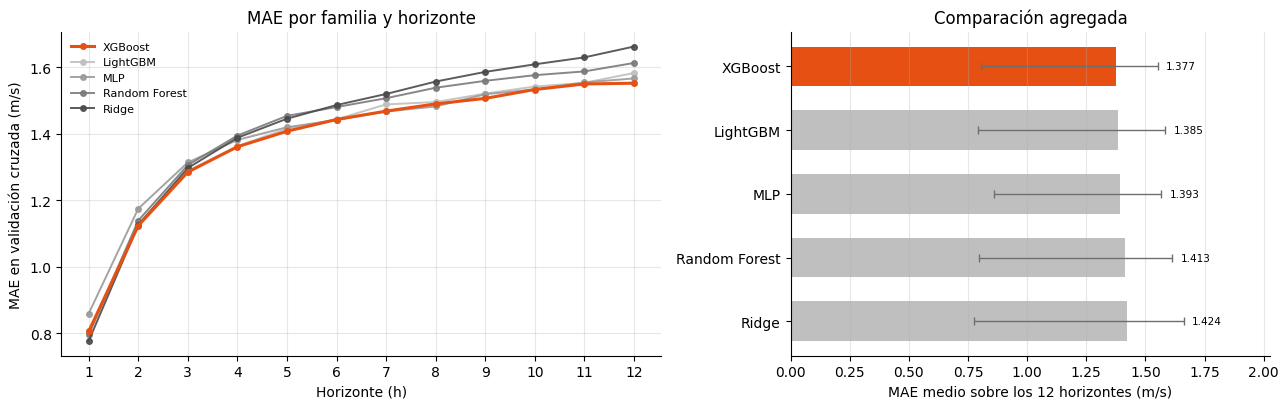

In [3]:
# --- Etapa 1: selección de familia sobre TODOS los horizontes -----------------
# Elegir la familia con un único horizonte de referencia haría la decisión
# dependiente de ese punto concreto: una familia puede ser superior a corto plazo
# (donde domina la persistencia) e inferior a plazos largos (donde pesa el
# pronóstico físico). Se evalúan por ello los doce horizontes y se selecciona la
# familia por su comportamiento agregado, no por un caso particular.

def objetivos_para(dev_h, F_h, H):
    """Funciones objetivo de Optuna para un horizonte dado."""
    def cv(fn, p):
        return cv_mae(fn, p, dev_h[F_h], dev_h[OBJ], H)

    def obj_ridge(t):
        fn = lambda **kw: make_pipeline(StandardScaler(), Ridge(**kw))
        return cv(fn, {'alpha': t.suggest_float('alpha', 1e-3, 100, log=True)})

    def obj_xgb(t):
        return cv(XGBRegressor, dict(
            n_estimators=t.suggest_int('n_estimators', 100, 500),
            max_depth=t.suggest_int('max_depth', 3, 8),
            learning_rate=t.suggest_float('learning_rate', .01, .3, log=True),
            subsample=t.suggest_float('subsample', .6, 1.0),
            colsample_bytree=t.suggest_float('colsample_bytree', .6, 1.0),
            n_jobs=N_JOBS_MODELO, verbosity=0, random_state=SEMILLA))

    def obj_lgbm(t):
        return cv(LGBMRegressor, dict(
            n_estimators=t.suggest_int('n_estimators', 100, 500),
            num_leaves=t.suggest_int('num_leaves', 15, 127),
            learning_rate=t.suggest_float('learning_rate', .01, .3, log=True),
            subsample=t.suggest_float('subsample', .6, 1.0),
            colsample_bytree=t.suggest_float('colsample_bytree', .6, 1.0),
            n_jobs=N_JOBS_MODELO, verbosity=-1, random_state=SEMILLA))

    def obj_mlp(t):
        capas = t.suggest_categorical('capas', ['64', '128', '64,32', '128,64'])
        fn = lambda **kw: make_pipeline(StandardScaler(), MLPRegressor(**kw))
        return cv(fn, dict(
            hidden_layer_sizes=tuple(int(x) for x in capas.split(',')),
            alpha=t.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init=t.suggest_float('lr_init', 1e-4, 1e-2, log=True),
            max_iter=300, early_stopping=True, random_state=SEMILLA))

    return {'Ridge': obj_ridge, 'XGBoost': obj_xgb,
            'LightGBM': obj_lgbm, 'MLP': obj_mlp}


def cv_mae(modelo_fn, params, X, y, H):
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV, gap=H)
    maes = []
    for i_tr, i_va in tscv.split(X):
        m = modelo_fn(**params)
        m.fit(X.iloc[i_tr], y.iloc[i_tr])
        maes.append(mean_absolute_error(y.iloc[i_va], m.predict(X.iloc[i_va])))
    return float(np.mean(maes))


def evaluar_familias(H):
    """MAE de validación cruzada de cada familia en un horizonte."""
    d_h, F_h = construir_dataset(H, 24)
    tr_h, va_h, _ = split_temporal(d_h)
    dev_h = pd.concat([tr_h, va_h])

    resultado = {}
    for nombre, obj in objetivos_para(dev_h, F_h, H).items():
        est = optuna.create_study(direction='minimize',
                                  sampler=optuna.samplers.TPESampler(seed=SEMILLA))
        est.optimize(obj, n_trials=TRIALS_FAMILIA, show_progress_bar=False)
        resultado[nombre] = est.best_value

    # Random Forest entra con una configuración única: su coste por ajuste es
    # aproximadamente diez veces el de XGBoost, y la búsqueda completa no
    # compensa dado el resultado que obtiene.
    resultado['Random Forest'] = cv_mae(
        RandomForestRegressor,
        dict(n_estimators=150, min_samples_leaf=5, max_depth=12,
             n_jobs=N_JOBS_MODELO, random_state=SEMILLA),
        dev_h[F_h], dev_h[OBJ], H)
    return H, resultado


t0 = time.time()
salidas = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(evaluar_familias)(H) for H in HORIZONTES)
print(f'Familias evaluadas en {len(HORIZONTES)} horizontes '
      f'({(time.time()-t0)/60:.1f} min)\n')

mae_familias = pd.DataFrame({H: r for H, r in sorted(salidas)})
mae_familias.index.name = 'familia'
display(mae_familias.round(3))

# --- Selección --------------------------------------------------------------
# Se atiende a dos criterios complementarios: el MAE medio sobre los doce
# horizontes y el número de horizontes en que cada familia resulta la mejor. Si
# ambos coinciden, la elección es sólida; si discrepan, es indicio de que el
# comportamiento depende del horizonte y conviene examinarlo.
resumen_familia = pd.DataFrame({
    'MAE_medio':  mae_familias.mean(axis=1),
    'MAE_min':    mae_familias.min(axis=1),
    'MAE_max':    mae_familias.max(axis=1),
    'veces_mejor': mae_familias.idxmin(axis=0).value_counts()
                                .reindex(mae_familias.index).fillna(0).astype(int),
}).sort_values('MAE_medio')
display(resumen_familia.round(3))

GANADOR = resumen_familia.index[0]
por_horizonte = resumen_familia.loc[GANADOR, 'veces_mejor']
print(f'Familia ganadora por MAE medio: {GANADOR} '
      f'(mejor en {por_horizonte} de los {len(HORIZONTES)} horizontes)')

ganador_h12 = mae_familias[H_REF].idxmin()
if ganador_h12 != GANADOR:
    print(f'AVISO: en H={H_REF} h la mejor familia sería {ganador_h12}. La elección '
          f'agregada difiere de la que habría producido un único horizonte.')

# --- FIGURA -----------------------------------------------------------------
NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2),
                         gridspec_kw={'width_ratios': [1.25, 1]})

# (a) evolución con el horizonte: revela si alguna familia depende del plazo
grises = ['#BFBFBF', '#9A9A9A', '#7A7A7A', '#4A4A4A']
i_gris = 0
for familia in resumen_familia.index:
    if familia == GANADOR:
        est = dict(color=NARANJA, lw=2.2, marker='o', zorder=5)
    else:
        est = dict(color=grises[i_gris % len(grises)], lw=1.4, marker='o', alpha=.9)
        i_gris += 1
    axes[0].plot(mae_familias.columns, mae_familias.loc[familia],
                 markersize=4, label=familia, **est)
axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE en validación cruzada (m/s)')
axes[0].set_title('MAE por familia y horizonte')
axes[0].set_xticks(list(mae_familias.columns))
axes[0].legend(fontsize=8, frameon=False)
axes[0].grid(alpha=.3)

# (b) MAE medio, con el rango entre horizontes como barra de error
orden = resumen_familia.index[::-1]
colores = [NARANJA if f == GANADOR else '#BFBFBF' for f in orden]
err = np.vstack([(resumen_familia.loc[orden, 'MAE_medio'] - resumen_familia.loc[orden, 'MAE_min']).values,
                 (resumen_familia.loc[orden, 'MAE_max'] - resumen_familia.loc[orden, 'MAE_medio']).values])
axes[1].barh(orden, resumen_familia.loc[orden, 'MAE_medio'], xerr=err,
             color=colores, height=.62, error_kw=dict(ecolor=GRIS, capsize=3, lw=1))
axes[1].set_xlabel('MAE medio sobre los 12 horizontes (m/s)')
axes[1].set_title('Comparación agregada')
axes[1].grid(axis='x', alpha=.3); axes[1].grid(axis='y', visible=False)
for f in orden:
    axes[1].annotate(f"{resumen_familia.loc[f, 'MAE_medio']:.3f}",
                     xy=(resumen_familia.loc[f, 'MAE_max'], f),
                     xytext=(6, 0), textcoords='offset points',
                     va='center', fontsize=7.5)
axes[1].set_xlim(0, resumen_familia.MAE_max.max() * 1.22)

for ax in axes:
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

plt.tight_layout()

NOMBRE = 'familias_ml'
from pathlib import Path
Path('figuras').mkdir(exist_ok=True)
for _fmt in ('pdf', 'png'):
    fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
print(f'figura guardada: figuras/{NOMBRE}.pdf')

plt.show()

---
## 3. Etapa 2 — Afinado por horizonte

Búsqueda conjunta de **ventana e hiperparámetros**: la ventana es una opción categórica más
del espacio de Optuna, porque su óptimo depende del resto de la configuración.

Dentro de cada fold, el modelo se entrena hasta `N_ESTIM_MAX` árboles y para tras
`EARLY_STOP` rondas sin mejora. El modelo final se reentrena sobre `train+val` con el número
de árboles ya decidido, para no desperdiciar las horas de validación.

> El afinado se implementa para XGBoost (`reg:absoluteerror`, early stopping nativo). Si la
> etapa 1 eligiera otra familia, la celda avisa y usa XGBoost como referencia afinable.

In [4]:
if GANADOR != 'XGBoost':
    print(f'AVISO: la etapa 1 eligió {GANADOR}, pero el afinado con early stopping y '
          f'reg:absoluteerror está implementado para XGBoost. Se afina XGBoost.')
MODELO_FINAL = 'XGBoost'

def cv_mae_afinado(H, W, params):
    d, F = construir_dataset(H, W)
    dev = d.iloc[:int(len(d)*.8)]        # train+val; el 20% de test no se toca
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_CV, gap=H)
    maes = []
    for i_tr, i_va in tscv.split(dev):
        m = XGBRegressor(**params, n_estimators=N_ESTIM_MAX, early_stopping_rounds=EARLY_STOP,
                         objective='reg:absoluteerror', n_jobs=N_JOBS_MODELO, verbosity=0,
                         random_state=SEMILLA)
        m.fit(dev.iloc[i_tr][F], dev.iloc[i_tr][OBJ],
              eval_set=[(dev.iloc[i_va][F], dev.iloc[i_va][OBJ])], verbose=False)
        maes.append(mean_absolute_error(dev.iloc[i_va][OBJ], m.predict(dev.iloc[i_va][F])))
    return float(np.mean(maes))

def hacer_objetivo(H):
    def obj(trial):
        W = trial.suggest_categorical('ventana', VENTANAS)
        p = dict(max_depth=trial.suggest_int('max_depth', 3, 9),
                 learning_rate=trial.suggest_float('learning_rate', .005, .3, log=True),
                 subsample=trial.suggest_float('subsample', .5, 1.0),
                 colsample_bytree=trial.suggest_float('colsample_bytree', .5, 1.0),
                 min_child_weight=trial.suggest_int('min_child_weight', 1, 20),
                 gamma=trial.suggest_float('gamma', 1e-8, 5, log=True),
                 reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
                 reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True))
        return cv_mae_afinado(H, W, p)
    return obj

def afinar_horizonte(H):
    """Búsqueda + reajuste final para un horizonte. Independiente del resto, así que
    los 12 horizontes se pueden repartir entre procesos."""
    t0 = time.time()
    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEMILLA),
                                pruner=optuna.pruners.MedianPruner(n_warmup_steps=5))
    study.optimize(hacer_objetivo(H), n_trials=TRIALS_AFINADO, show_progress_bar=False)

    W  = study.best_params['ventana']
    hp = {k: v for k, v in study.best_params.items() if k != 'ventana'}

    d, F = construir_dataset(H, W)
    tr, va, te = split_temporal(d)
    dev_h = pd.concat([tr, va])

    # 1) early stopping con 'va' para fijar el nº de árboles
    m_es = XGBRegressor(**hp, n_estimators=N_ESTIM_MAX, early_stopping_rounds=EARLY_STOP,
                        objective='reg:absoluteerror', n_jobs=N_JOBS_MODELO, verbosity=0,
                        random_state=SEMILLA)
    m_es.fit(tr[F], tr[OBJ], eval_set=[(va[F], va[OBJ])], verbose=False)

    # 2) reentrenamiento sobre train+val con ese nº de árboles ya decidido
    m_final = XGBRegressor(**hp, n_estimators=max(m_es.best_iteration, 10),
                           objective='reg:absoluteerror', n_jobs=N_JOBS_MODELO, verbosity=0,
                           random_state=SEMILLA)
    m_final.fit(dev_h[F], dev_h[OBJ])

    pred_test = pd.Series(m_final.predict(te[F]), index=te.index, name=MODELO_FINAL)
    return {'H': H, 'ventana': W, 'n_arboles': int(m_es.best_iteration),
            'MAE': mean_absolute_error(te[OBJ], pred_test),
            'RMSE': np.sqrt(mean_squared_error(te[OBJ], pred_test)),
            'n_test': len(te), 'params': hp, 'segundos': time.time()-t0,
            'modelo': m_final, 'features': F, 'test': te, 'pred': pred_test}

t_ini = time.time()
salidas = Parallel(n_jobs=N_JOBS_HORIZONTE, backend='loky')(
    delayed(afinar_horizonte)(H) for H in HORIZONTES)
print(f'Afinado de {len(HORIZONTES)} horizontes en {(time.time()-t_ini)/60:.1f} min '
      f'({N_JOBS_HORIZONTE} en paralelo x {N_JOBS_MODELO} hilos)\n')

resultados, modelos_finales, predicciones_finales = [], {}, {}
for s in sorted(salidas, key=lambda r: r['H']):
    H = s['H']
    modelos_finales[H]      = (s['modelo'], s['features'], s['test'])
    predicciones_finales[H] = s['pred']
    resultados.append({k: s[k] for k in
                       ('H', 'ventana', 'n_arboles', 'MAE', 'RMSE', 'n_test', 'params')})
    print(f"H={H:>2}  ventana={s['ventana']:>2}  árboles={s['n_arboles']:>4}  "
          f"MAE={s['MAE']:.3f}  RMSE={s['RMSE']:.3f}  ({s['segundos']:.0f}s)")

tabla_final = pd.DataFrame(resultados)

[I 2026-10-03 16:41:03,659] A new study created in memory with name: no-name-fac6d27e-d365-4a68-b311-9318583058f7
[I 2026-10-03 16:41:03,678] A new study created in memory with name: no-name-969d2cec-d7ad-4043-88a7-54d7a1a871cb
[I 2026-10-03 16:41:03,692] A new study created in memory with name: no-name-57f8f9e6-fc6f-4520-9bdd-577d9f5fc2fa
[I 2026-10-03 16:41:15,835] Trial 0 finished with value: 1.129784697907403 and parameters: {'ventana': 12, 'max_depth': 7, 'learning_rate': 0.009470976192691145, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'min_child_weight': 18, 'gamma': 0.0016946556203947059, 'reg_alpha': 0.02358594058414266, 'reg_lambda': 1.5320059381854043e-08}. Best is trial 0 with value: 1.129784697907403.
[I 2026-10-03 16:41:16,081] Trial 0 finished with value: 1.274102625871268 and parameters: {'ventana': 12, 'max_depth': 7, 'learning_rate': 0.009470976192691145, 'subsample': 0.5779972601681014, 'colsample_bytree': 0.5290418060840998, 'min_child_w

Afinado de 12 horizontes en 78.7 min (3 en paralelo x 2 hilos)

H= 1  ventana= 6  árboles=1899  MAE=0.767  RMSE=1.082  (1889s)
H= 2  ventana= 6  árboles=1567  MAE=1.099  RMSE=1.499  (1993s)
H= 3  ventana= 6  árboles=1193  MAE=1.256  RMSE=1.711  (1325s)
H= 4  ventana=12  árboles= 658  MAE=1.357  RMSE=1.853  (1072s)
H= 5  ventana=12  árboles= 516  MAE=1.406  RMSE=1.933  (1606s)
H= 6  ventana=12  árboles= 676  MAE=1.439  RMSE=1.977  (1037s)
H= 7  ventana=12  árboles= 149  MAE=1.469  RMSE=2.007  (707s)
H= 8  ventana=12  árboles= 766  MAE=1.486  RMSE=2.039  (1077s)
H= 9  ventana=12  árboles= 341  MAE=1.504  RMSE=2.046  (715s)
H=10  ventana= 6  árboles=1096  MAE=1.507  RMSE=2.033  (1228s)
H=11  ventana=12  árboles= 969  MAE=1.517  RMSE=2.043  (687s)
H=12  ventana=12  árboles=  65  MAE=1.521  RMSE=2.057  (338s)


---
## 4. Comparación con los baselines del notebook 3

ML frente a SARIMA, SARIMAX y HARMONIE bruto, horizonte a horizonte, cada uno sobre su
propia muestra de evaluación. Es una comparación orientativa: la definitiva, sobre la
intersección horaria común a todos los modelos, se hace en el notebook 6.

,H,ventana,n_arboles,MAE,RMSE,n_test
0,1,6,1899,0.767,1.082,4716
1,2,6,1567,1.099,1.499,4706
2,3,6,1193,1.256,1.711,4695
3,4,12,658,1.357,1.853,4615
4,5,12,516,1.406,1.933,4546
5,6,12,676,1.439,1.977,4478
6,7,12,149,1.469,2.007,4409
7,8,12,766,1.486,2.039,4341
8,9,12,341,1.504,2.046,4273
9,10,6,1096,1.507,2.033,4215


H,1,2,3,4,5,6,7,8,9,10,11,12
modelo,,,,,,,,,,,,
HARMONIE bruto,2.751,2.756,2.764,2.775,2.778,2.780,2.785,2.791,2.791,2.790,2.790,2.795
SARIMAX (+HARMONIE),0.792,1.182,1.431,1.647,1.829,2.023,2.168,2.362,2.465,2.600,2.720,2.802
XGBoost (ML),0.767,1.099,1.256,1.357,1.406,1.439,1.469,1.486,1.504,1.507,1.517,1.521


figura guardada: figuras/ml_vs_baselines.pdf


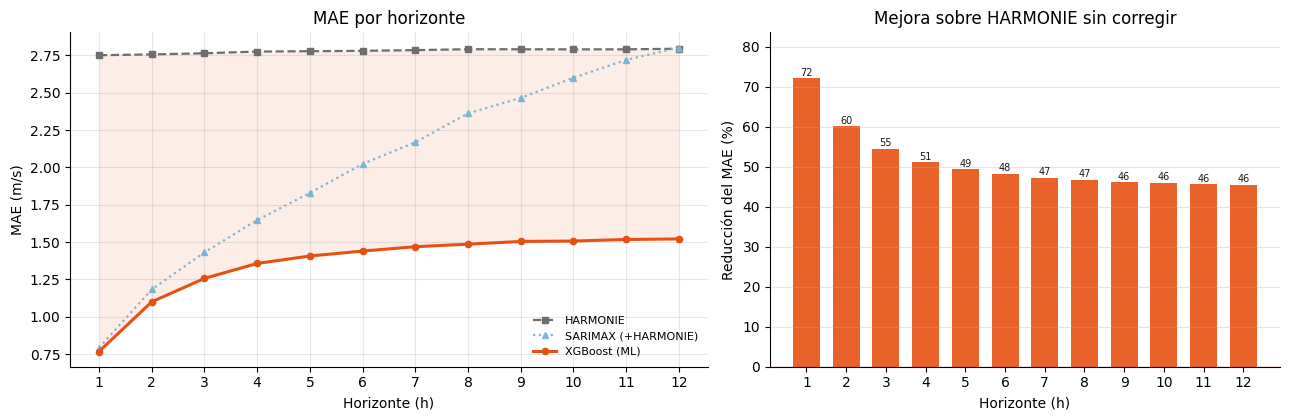

Mejora del ML sobre HARMONIE sin corregir (%):
H
1     72.1
2     60.1
3     54.5
4     51.1
5     49.4
6     48.2
7     47.3
8     46.8
9     46.1
10    46.0
11    45.6
12    45.6


In [5]:
display(tabla_final[['H', 'ventana', 'n_arboles', 'MAE', 'RMSE', 'n_test']].round(3))

if baselines is not None:
    # Se compara contra HARMONIE sin corregir (la referencia operativa) y contra
    # SARIMAX (el baseline estadístico fuerte). SARIMA puro se omite: su papel
    # —cuantificar la aportación de la exógena— ya quedó documentado en el
    # notebook 3, y aquí solo añadiría una curva que satura la figura.
    comp = (baselines[baselines.modelo.isin(['HARMONIE bruto', 'SARIMAX (+HARMONIE)'])]
            .pivot(index='modelo', columns='H', values='MAE'))
    comp.loc[f'{MODELO_FINAL} (ML)'] = tabla_final.set_index('H')['MAE']
    comp = comp[sorted(comp.columns)]
    display(comp.round(3))

    mejora = 100*(comp.loc['HARMONIE bruto'] - comp.loc[f'{MODELO_FINAL} (ML)'])/comp.loc['HARMONIE bruto']

    NARANJA = '#E65113'   # naranja corporativo del documento
    GRIS    = '#6E6E6E'

    # El naranja se reserva para el modelo de ML, protagonista de la figura; el
    # gris para la referencia operativa y el azul para el baseline estadístico.
    ESTILO_MOD = {
        'HARMONIE bruto':          dict(color=GRIS,    ls='--', marker='s', lw=1.6),
        'SARIMAX (+HARMONIE)':     dict(color='#7FB3D5', ls=':', marker='^', lw=1.6),
        f'{MODELO_FINAL} (ML)':    dict(color=NARANJA, ls='-',  marker='o', lw=2.2),
    }
    ETIQUETA = {'HARMONIE bruto': 'HARMONIE',
                'SARIMAX (+HARMONIE)': 'SARIMAX (+HARMONIE)',
                f'{MODELO_FINAL} (ML)': f'{MODELO_FINAL} (ML)'}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.3),
                             gridspec_kw={'width_ratios': [1.25, 1]})

    # (a) MAE por horizonte
    orden = ['HARMONIE bruto', 'SARIMAX (+HARMONIE)', f'{MODELO_FINAL} (ML)']
    for modelo in [m for m in orden if m in comp.index]:
        axes[0].plot(comp.columns, comp.loc[modelo], markersize=4.5,
                     label=ETIQUETA.get(modelo, modelo), **ESTILO_MOD[modelo])
    # El área sombreada visualiza la corrección aportada sobre el pronóstico
    # operativo, que es la magnitud que justifica el trabajo.
    axes[0].fill_between(comp.columns, comp.loc[f'{MODELO_FINAL} (ML)'],
                         comp.loc['HARMONIE bruto'],
                         color=NARANJA, alpha=.10, lw=0, zorder=0)
    axes[0].set_xlabel('Horizonte (h)'); axes[0].set_ylabel('MAE (m/s)')
    axes[0].set_title('MAE por horizonte')
    axes[0].set_xticks(list(comp.columns))
    axes[0].legend(fontsize=8, frameon=False)
    axes[0].grid(alpha=.3)

    # (b) Reducción del error respecto al pronóstico sin corregir
    barras = axes[1].bar(comp.columns, mejora.values, color=NARANJA, alpha=.9, width=.68)
    axes[1].axhline(0, color=NARANJA, lw=.9)
    axes[1].set_xlabel('Horizonte (h)'); axes[1].set_ylabel('Reducción del MAE (%)')
    axes[1].set_title('Mejora sobre HARMONIE sin corregir')
    axes[1].set_xticks(list(comp.columns))
    axes[1].set_ylim(0, mejora.max() * 1.16)
    axes[1].grid(axis='y', alpha=.3)
    for barra, valor in zip(barras, mejora.values):
        axes[1].annotate(f'{valor:.0f}', xy=(barra.get_x() + barra.get_width()/2, valor),
                         xytext=(0, 2), textcoords='offset points',
                         ha='center', fontsize=7, color='#1A1A1A')

    for ax in axes:
        for lado in ('top', 'right'):
            ax.spines[lado].set_visible(False)

    plt.tight_layout()

    NOMBRE = 'ml_vs_baselines'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.show()

    print('Mejora del ML sobre HARMONIE sin corregir (%):')
    print(mejora.round(1).to_string())

---
## 5. Estabilidad de los hiperparámetros e importancia de las features

Si los hiperparámetros óptimos varían poco entre horizontes, el problema tiene estructura
estable y la búsqueda no está sobreajustando a cada muestra concreta.

La importancia responde además a si las features de tendencia (`lag_media`, `lag_std`,
`lag_tend`) aportan o el modelo las ignora en favor de `H_vel`.

In [6]:
params_tabla = pd.DataFrame([r['params'] for r in resultados],
                            index=[r['H'] for r in resultados])
params_tabla.index.name = 'H'
display(params_tabla.round(4))

m_ref, F_ref, te_ref = modelos_finales[H_REF]
imp = pd.Series(m_ref.feature_importances_, index=F_ref).sort_values(ascending=False)
display(imp.head(12).to_frame('importancia').round(4))

print(f'Posición de las features de tendencia (de {len(F_ref)} features):')
for t in TREND:
    if t in imp.index:
        print(f'  {t:10s} posición {list(imp.index).index(t)+1:>3}   importancia {imp[t]:.4f}')

,max_depth,learning_rate,subsample,colsample_bytree,min_child_weight,gamma,reg_alpha,reg_lambda
H,,,,,,,,
1,8,0.0056,0.5231,0.9744,19,0.0000,4.0449,0.0021
2,5,0.0055,0.5008,0.9155,20,3.5202,0.8650,0.0000
3,5,0.0078,0.5030,0.6850,19,0.0001,0.0000,0.0000
4,5,0.0121,0.5786,0.7691,19,0.0000,0.0000,1.5788
5,4,0.0189,0.5788,0.8030,18,0.0003,0.0004,0.0000
6,4,0.0160,0.5106,0.9168,11,0.0001,0.0000,0.0000
7,4,0.0564,0.5368,0.9267,12,0.0000,0.0031,0.3581
8,3,0.0108,0.5427,0.9395,10,0.0000,0.0015,0.0001
9,3,0.0408,0.6240,0.9195,15,0.0010,0.0370,0.0000


,importancia
H_vel,0.3987
lag12,0.1226
H_dir_sin,0.0898
lag_media,0.0500
lag13,0.0393
dia_cos,0.0292
hora_cos,0.0276
dia_sin,0.0252
H_dir_cos,0.0221
lag22,0.0210


Posición de las features de tendencia (de 23 features):
  lag_media  posición   4   importancia 0.0500
  lag_std    posición  18   importancia 0.0129
  lag_tend   posición  23   importancia 0.0097


---
## 6. Ejemplo de predicción: un episodio concreto

Las métricas agregadas resumen miles de horas y ocultan el comportamiento del
modelo ante un evento concreto. Esta sección reconstruye un caso de uso
operativo: se fija un instante de decisión $t_0$ y se representan las horas
previas observadas ---la información de que dispone el operador--- junto con lo
que el modelo pronostica para las doce horas siguientes.

Se emplea un episodio de **levante sostenido** (3 de agosto de 2022), en el que
el viento se mantiene por encima del umbral durante las doce horas: el tipo de
evento en que una desactivación prematura del sistema de seguridad sería un error.

Como allí, cada punto de la curva procede de un modelo distinto: el valor a seis
horas es la predicción del modelo entrenado a horizonte 6~h, no un paso
intermedio de una predicción a doce horas.

Instante de decisión: 2022-08-03 06:00:00
Horizontes con predicción disponible: 12 de 12


,real,H,momento,XGBoost,HARMONIE,SARIMAX,err XGBoost,err HARMONIE,err SARIMAX
ts,,,,,,,,,
2022-08-03 01:00:00,16.78,-5,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 02:00:00,17.16,-4,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 03:00:00,16.90,-3,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 04:00:00,15.90,-2,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 05:00:00,16.67,-1,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 06:00:00,15.18,0,historia,NaN,NaN,NaN,NaN,NaN,NaN
2022-08-03 07:00:00,14.12,1,predicción,14.64,11.14,15.03,0.52,2.98,0.91
2022-08-03 08:00:00,14.18,2,predicción,14.82,10.58,14.97,0.64,3.60,0.78
2022-08-03 09:00:00,14.29,3,predicción,14.42,10.34,14.64,0.13,3.95,0.35


figura guardada: figuras/episodio_ml.pdf


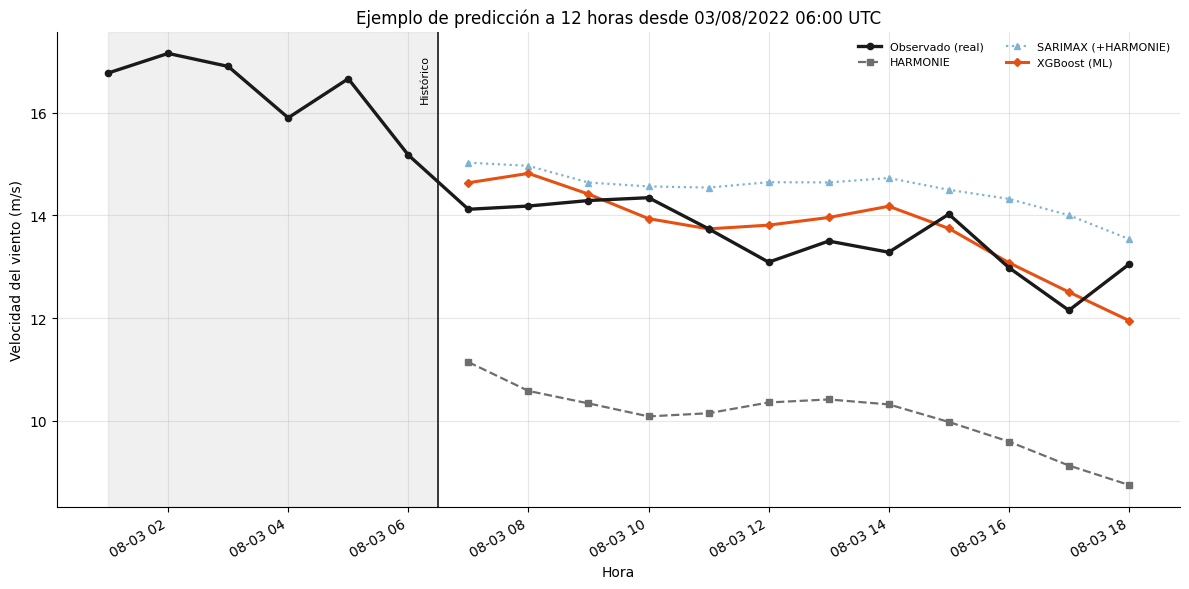

MAE en este episodio (12 h):
  XGBoost (ML)            0.47 m/s
  SARIMAX (+HARMONIE)     0.95 m/s
  HARMONIE                3.50 m/s
  (promedio global de XGBoost sobre todo el test: 1.36 m/s)

Descenso por debajo del umbral (11.5 m/s): real en h=None
  XGBoost (ML)           h=None   desviación: —
  SARIMAX (+HARMONIE)    h=None   desviación: —
  HARMONIE               h=   1   desviación: —

(un episodio concreto puede desviarse del promedio: se muestra con
 propósito ilustrativo, no como evidencia de rendimiento)


In [7]:
# --- Configuración del ejemplo ------------------------------------------------
N_PREVIAS = 6      # horas de historia observada previa al instante de decisión
UMBRAL = 11.5      # m/s, umbral de activación de seguridad

# Instante de decisión del ejemplo. Con None se elige automáticamente; para
# examinar un episodio concreto, indíquese su fecha:
#     T0_MANUAL = pd.Timestamp(2022, 8, 8, 0)
# El índice del dataset no lleva zona horaria, así que la marca tampoco debe
# llevarla. Si la fecha indicada no tiene predicción en los doce horizontes, la
# celda avisa y sugiere las más próximas que sí la tienen.
T0_MANUAL = pd.Timestamp(2022, 8, 3, 6)

# El conjunto de test de este notebook (60/20/20 cronológico) no coincide con el
# del notebook 3 (walk-forward multi-tramo), de modo que el episodio allí
# empleado puede quedar fuera de rango. La selección automática toma, entre los
# instantes con predicción en los doce horizontes, el de mayor recorrido de
# viento que además cruce el umbral de activación: es donde la calidad del
# pronóstico decide la actuación del sistema.
def instantes_completos():
    comun = None
    for H in HORIZONTES:
        serie = predicciones_finales.get(H)
        if serie is None:
            return []
        t0 = set(serie.dropna().index - pd.Timedelta(hours=H))
        comun = t0 if comun is None else comun & t0
    return sorted(comun or [])

def elegir_episodio():
    recorrido = {}
    for t0 in instantes_completos():
        fut = base[OBJ].reindex(pd.date_range(t0 + pd.Timedelta(hours=1),
                                              t0 + pd.Timedelta(hours=max(HORIZONTES)),
                                              freq='h'))
        # Interesa un episodio que cruce el umbral: es donde la predicción decide
        if fut.notna().all() and (fut >= UMBRAL).any() and (fut < UMBRAL).any():
            recorrido[t0] = fut.max() - fut.min()
    if not recorrido:
        candidatos = instantes_completos()
        return candidatos[len(candidatos)//2] if candidatos else None
    return max(recorrido, key=recorrido.get)

def resolver_t0():
    """Devuelve el instante de decisión, validando el elegido a mano."""
    validos = instantes_completos()
    if T0_MANUAL is None:
        return elegir_episodio()

    t0 = pd.Timestamp(T0_MANUAL)
    if t0.tzinfo is not None:          # el índice del dataset es naive
        t0 = t0.tz_localize(None)
    if t0 in set(validos):
        return t0

    print(f'AVISO: {t0} no tiene predicción en los doce horizontes.')
    if validos:
        cercanos = sorted(validos, key=lambda x: abs(x - t0))[:3]
        print('       Instantes válidos más próximos: '
              + ', '.join(str(c) for c in cercanos))
        print(f'       Rango disponible: {validos[0]} a {validos[-1]}')
        print('       Se emplea la selección automática.')
    return elegir_episodio()


T0 = resolver_t0()

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'
NEGRO   = '#1A1A1A'

def serie_episodio(t0):
    """Historia previa, predicción del modelo por horizonte y valor real.

    El índice cubre de forma continua desde t0-N_PREVIAS+1 hasta t0+max(H), sin
    solapes: t0 pertenece a la historia (es el último dato conocido) y las
    predicciones empiezan en t0+1. El horizonte de cada fila se deriva de la
    diferencia temporal con t0, no de su posición, para que el cálculo no
    dependa de cómo se construyó el índice.
    """
    idx = pd.date_range(t0 - pd.Timedelta(hours=N_PREVIAS - 1),
                        t0 + pd.Timedelta(hours=max(HORIZONTES)), freq='h')

    ep = pd.DataFrame(index=idx)
    ep.index.name = 'ts'
    ep['real'] = base[OBJ].reindex(ep.index)
    ep['H'] = ((ep.index - t0) / pd.Timedelta(hours=1)).astype(int)
    ep['momento'] = np.where(ep.H <= 0, 'historia', 'predicción')

    ep[MODELO_FINAL] = [
        predicciones_finales[H].get(ts, np.nan)
        if H >= 1 and H in predicciones_finales else np.nan
        for ts, H in zip(ep.index, ep.H)]
    return ep

# Se incorpora HARMONIE sin corregir como referencia: el interés del ejemplo
# está en ver qué corrige el modelo sobre el pronóstico físico, no solo su error.
# Cada horizonte emplea su propia pasada (lead >= H + LATENCIA), de modo que la
# referencia respeta la misma restricción temporal que el modelo.
if T0 is None:
    raise RuntimeError('No hay ningún instante con predicción en los 12 horizontes.')

ep = serie_episodio(T0)

# Cada horizonte emplea su propia pasada (lead >= H + LATENCIA). Se cachean las
# series para no reconstruirlas en cada iteración.
_harm_cache = {H: harmonie_para(H)['H_vel'] for H in HORIZONTES}
ep['HARMONIE'] = [_harm_cache[H].get(ts, np.nan) if H in _harm_cache else np.nan
                  for ts, H in zip(ep.index, ep.H)]

# SARIMAX se recupera del parquet del notebook 3. Su conjunto de test es más
# amplio que el de este notebook (walk-forward multi-tramo frente a 60/20/20),
# de modo que normalmente cubre el episodio; si no lo cubriera, la serie queda a
# NaN y simplemente no se representa.
MODELO_SARIMAX = 'SARIMAX (+HARMONIE)'
ruta_baselines = RUTA/'baselines_predicciones.parquet'
if ruta_baselines.exists():
    _bl = pd.read_parquet(ruta_baselines)
    _bl['ts'] = pd.to_datetime(_bl['ts'])
    _sx = {int(H): g.set_index('ts')['pred'].sort_index()
           for H, g in _bl[_bl.modelo == MODELO_SARIMAX].groupby('H')}
    ep['SARIMAX'] = [_sx[H].get(ts, np.nan) if H in _sx else np.nan
                     for ts, H in zip(ep.index, ep.H)]
else:
    ep['SARIMAX'] = np.nan
    print('AVISO: no se encuentra baselines_predicciones.parquet; '
          'se omite SARIMAX del ejemplo.')

fut = ep[ep.momento == 'predicción']
disponibles = fut[MODELO_FINAL].notna().sum()
print(f'Instante de decisión: {T0}')
print(f'Horizontes con predicción disponible: {disponibles} de {len(fut)}')

if disponibles == 0:
    print('El episodio no está cubierto por el conjunto de test; '
          'elíjase otro instante T0 dentro del periodo de evaluación.')
else:
    tabla_ep = ep.copy()
    for m in [MODELO_FINAL, 'HARMONIE', 'SARIMAX']:
        if tabla_ep[m].notna().any():
            tabla_ep[f'err {m}'] = (tabla_ep[m] - tabla_ep['real']).abs()
    display(tabla_ep.round(2))

    # --- FIGURA -------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(ep.index, ep['real'], color=NEGRO, ls='-', marker='o', lw=2.4,
            markersize=4.5, label='Observado (real)', zorder=5)
    # El corte se sitúa a mitad de camino entre t0 y la primera hora predicha:
    # así la separación cae en el hueco entre ambas series y no sobre el último
    # punto observado, que todavía pertenece a la historia.
    CORTE_VISUAL = T0 + pd.Timedelta(minutes=30)
    ax.axvspan(ep.index[0], CORTE_VISUAL, color=GRIS, alpha=.10, zorder=0)
    ax.axvline(CORTE_VISUAL, color=NEGRO, lw=1.2)
    ax.annotate('Histórico', xy=(CORTE_VISUAL, ax.get_ylim()[1]), xytext=(-6, -10),
                textcoords='offset points', ha='right', va='top',
                fontsize=8, rotation=90)

    if ep['HARMONIE'].notna().any():
        ax.plot(fut.index, fut['HARMONIE'], color=GRIS, ls='--',
                marker='s', lw=1.6, markersize=4.5, label='HARMONIE')
    if ep['SARIMAX'].notna().any():
        ax.plot(fut.index, fut['SARIMAX'], color='#7FB3D5', ls=':',
                marker='^', lw=1.6, markersize=4.5, label='SARIMAX (+HARMONIE)')
    ax.plot(fut.index, fut[MODELO_FINAL], color=NARANJA, ls='-', marker='D',
            lw=2.2, markersize=4.5, label=f'{MODELO_FINAL} (ML)')


    ax.set_xlabel('Hora'); ax.set_ylabel('Velocidad del viento (m/s)')
    ax.set_title(f'Ejemplo de predicción a 12 horas desde {T0:%d/%m/%Y %H:%M} UTC')
    ax.legend(fontsize=8, frameon=False, ncol=2)
    ax.grid(alpha=.3)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)
    fig.autofmt_xdate(rotation=30, ha='right')
    plt.tight_layout()

    NOMBRE = 'episodio_ml'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.show()

    # --- Error del episodio, por modelo -------------------------------------
    print('MAE en este episodio (12 h):')
    for m, etq in [(MODELO_FINAL, f'{MODELO_FINAL} (ML)'),
                   ('SARIMAX', 'SARIMAX (+HARMONIE)'),
                   ('HARMONIE', 'HARMONIE')]:
        if fut[m].notna().any():
            print(f'  {etq:22s} {(fut[m] - fut["real"]).abs().mean():5.2f} m/s')
    print(f'  (promedio global de {MODELO_FINAL} sobre todo el test: '
          f'{tabla_final.MAE.mean():.2f} m/s)')

    # ¿Detecta el modelo el descenso por debajo del umbral? Es lo que decide si
    # el sistema de seguridad actúa correctamente.
    def primera_bajada(serie):
        for i, v in enumerate(serie, start=1):
            if pd.notna(v) and v < UMBRAL:
                return i
        return None
    h_real = primera_bajada(fut['real'])
    print(f'\nDescenso por debajo del umbral ({UMBRAL} m/s): real en h={h_real}')
    for m, etq in [(MODELO_FINAL, f'{MODELO_FINAL} (ML)'),
                   ('SARIMAX', 'SARIMAX (+HARMONIE)'),
                   ('HARMONIE', 'HARMONIE')]:
        if fut[m].notna().any():
            h = primera_bajada(fut[m])
            desv = '—' if h is None or h_real is None else f'{h - h_real:+d} h'
            print(f'  {etq:22s} h={str(h):>4}   desviación: {desv}')
    print('\n(un episodio concreto puede desviarse del promedio: se muestra con')
    print(' propósito ilustrativo, no como evidencia de rendimiento)')

---
## 7. Interpretabilidad (SHAP)

Objetivo 2 del Anexo: explicabilidad mediante SHAP, sobre el modelo del horizonte de
referencia.

* Si `H_vel` domina, el modelo se apoya sobre todo en el pronóstico físico.
* Si pesan los lags recientes, está usando además persistencia local.
* `H_dir_sin`/`H_dir_cos` con impacto alto confirmarían el hallazgo del notebook 2: el
  régimen (levante/poniente) es informativo para corregir el sesgo de intensidad.

figura guardada: figuras/shap_xgboost.pdf


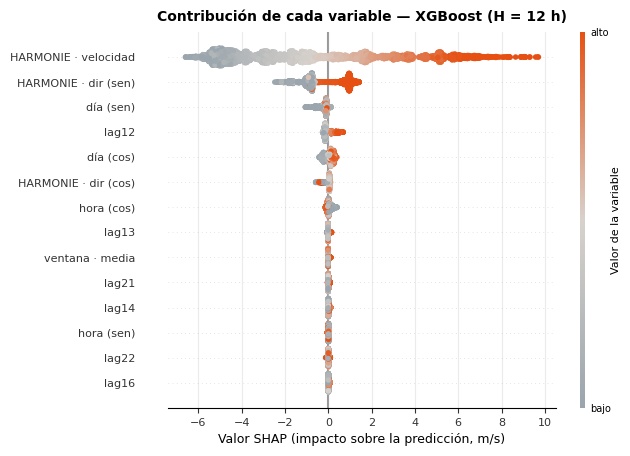

In [8]:
import shap
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FixedLocator, FixedFormatter

NARANJA = '#E65113'   # naranja corporativo del documento
GRIS    = '#6E6E6E'

# SHAP construye la figura por su cuenta y llama internamente a tight_layout(),
# incompatible con constrained_layout si estuviera activo. Se desactiva ANTES de
# crear la figura (hacerlo después ya no evita el conflicto) y se restaura al
# terminar, para no afectar al resto de figuras del notebook.
_cl_previo = mpl.rcParams['figure.constrained_layout.use']
mpl.rcParams['figure.constrained_layout.use'] = False

try:
    explainer = shap.TreeExplainer(m_ref)
    sv = explainer.shap_values(te_ref[F_ref])

    # Nombres legibles solo en la figura; no altera el modelo
    nombres = [f.replace('H_vel', 'HARMONIE · velocidad')
                .replace('H_dir_sin', 'HARMONIE · dir (sen)')
                .replace('H_dir_cos', 'HARMONIE · dir (cos)')
                .replace('H_lead', 'HARMONIE · lead')
                .replace('lag_media', 'ventana · media')
                .replace('lag_std', 'ventana · desv. típica')
                .replace('lag_tend', 'ventana · tendencia')
                .replace('hora_sin', 'hora (sen)').replace('hora_cos', 'hora (cos)')
                .replace('dia_sin', 'día (sen)').replace('dia_cos', 'día (cos)')
               for f in F_ref]

    # Escala de color propia en lugar del azul-rojo por defecto de SHAP: gris
    # para los valores bajos de la variable y naranja corporativo para los altos.
    cmap_tfm = LinearSegmentedColormap.from_list('tfm', ['#9AA5AD', '#D8D2CC', NARANJA])

    shap.summary_plot(sv, te_ref[F_ref], feature_names=nombres, max_display=14,
                      cmap=cmap_tfm, show=False, plot_size=(7.5, 4.6))

    fig = plt.gcf()
    ax = plt.gca()
    ax.set_xlabel('Valor SHAP (impacto sobre la predicción, m/s)', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.set_title(f'Contribución de cada variable — {MODELO_FINAL} (H = {H_REF} h)',
                 fontsize=10, fontweight='bold', pad=8)
    ax.grid(axis='x', alpha=.25)
    ax.set_axisbelow(True)
    for lado in ('top', 'right'):
        ax.spines[lado].set_visible(False)

    # La barra de color de SHAP se rotula en inglés ('High'/'Low') y con
    # tipografía desproporcionada. Fijar el formateador es lo único que persiste:
    # reescribir las etiquetas no basta, porque matplotlib las regenera al
    # renderizar.
    for eje in fig.axes:
        if eje is ax:
            continue
        eje.set_ylabel('Valor de la variable', fontsize=8)
        lo, hi = eje.get_ylim()
        eje.yaxis.set_major_locator(FixedLocator([lo, hi]))
        eje.yaxis.set_major_formatter(FixedFormatter(['bajo', 'alto']))
        eje.tick_params(labelsize=7, length=0)

    NOMBRE = 'shap_xgboost'
    from pathlib import Path
    Path('figuras').mkdir(exist_ok=True)
    for _fmt in ('pdf', 'png'):
        fig.savefig(f'figuras/{NOMBRE}.{_fmt}', format=_fmt, dpi=400, bbox_inches='tight')
    print(f'figura guardada: figuras/{NOMBRE}.pdf')

    plt.show()
finally:
    mpl.rcParams['figure.constrained_layout.use'] = _cl_previo

---
## 8. Guardado

Formato fijado por el notebook 6 (ensemble + Diebold-Mariano), que espera el modelo
etiquetado como `XGBoost (ML)`, y por los notebooks 7 (despliegue) y 8 (MLflow), que leen este fichero.

In [9]:
ml_df = pd.concat([
    pred.rename('pred').to_frame()
        .assign(H=H, modelo=f'{MODELO_FINAL} (ML)', real=base[OBJ].reindex(pred.index))
        .reset_index().rename(columns={'index': 'ts'})
    for H, pred in predicciones_finales.items()
], ignore_index=True)
ml_df.to_parquet(RUTA/'ml_predicciones.parquet', index=False)

with open(RUTA/'ml_mejor_modelo.json', 'w') as f:
    json.dump({'ganador': MODELO_FINAL,
               'familia_elegida_etapa1': GANADOR,
               'objective': 'reg:absoluteerror',
               'ventana_por_horizonte': {int(r['H']): r['ventana'] for r in resultados},
               # Se guardan TAMBIÉN los hiperparámetros: sin ellos, el notebook 8 no puede
               # reconstruir el modelo exacto y tendría que reoptimizar para desplegarlo.
               'metricas': resultados},
              f, indent=2, ensure_ascii=False, default=str)

print(f'Guardado ml_predicciones.parquet ({len(ml_df)} filas) y ml_mejor_modelo.json')

Guardado ml_predicciones.parquet (53194 filas) y ml_mejor_modelo.json


---
## Conclusiones

**Resumen:**

* Qué familia ganó la etapa 1 y por qué margen — justifica la elección del modelo en vez de
  presentarla como dada.
* La ventana óptima por horizonte: que varíe confirma que tratarla como hiperparámetro,
  y no fijarla de antemano, era la decisión correcta.
* La tabla ML / SARIMAX / HARMONIE bruto por horizonte es orientativa; la definitiva se calcula en el notebook 6 sobre la intersección común.
* La lectura del SHAP: qué tipo de información pesa más en la predicción.

**Limitaciones:** el afinado está atado a XGBoost (`reg:absoluteerror` + early stopping
nativo); otra familia ganadora exigiría reimplementar esa etapa. Ir más allá en optimización
(cientos de trials, stacking de semillas) tiene rendimientos decrecientes.

**Ficheros generados:**

| Fichero | Consumido por |
|---|---|
| `ml_predicciones.parquet` | Notebook 6 (ensemble + Diebold-Mariano) |
| ml_mejor_modelo.json | Notebooks 5 (comparación DL), 7 (despliegue) y 8 (MLflow) |

**Siguiente:** notebook 5 — Deep Learning (LSTM, GRU, Transformer), contra este listón.